In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from xgboost import XGBClassifier

In [8]:
#!wget -O raw_data/data.zip 'https://ndownloader.figshare.com/files/944109'

In [9]:
#!unzip raw_data/example.zip

In [10]:
path = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/Data File/PPG-BP dataset.xlsx'

df = pd.read_excel(path, header=1)
df.head()

,Num.,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
0,1,2,Female,45,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN
1,2,3,Female,50,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN
2,3,6,Female,47,150,47,101,71,79,20.888889,Normal,NaN,NaN,NaN
3,4,8,Male,45,172,65,136,93,87,21.971336,Prehypertension,NaN,NaN,NaN
4,5,9,Female,46,155,65,123,73,73,27.055151,Prehypertension,NaN,NaN,NaN


In [11]:
df1 = df.copy()

In [12]:
'''
Droping the ID columns
'''

df1 = df.drop(columns=['Num.', 'subject_ID'])

In [13]:
df1.head(2)

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
0,Female,45,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN
1,Female,50,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN


In [14]:
df1['Diabetes'] = df1['Diabetes'].replace('Type 2 Diabetes', 'Diabetes')

In [15]:
df1['Diabetes'].value_counts()

Diabetes
Diabetes    38
Name: count, dtype: int64

In [16]:
'''
Binaryzing Diabetes to 0 = Normal and 1 = Diabetes
'''

map_diabetes = {
    np.nan: 0,
    'Diabetes': 1
}

df1['Diabetes'] = df1['Diabetes'].map(map_diabetes)

In [17]:
'''
Binaryzing Sex to 0 = Female and 1 = Male
'''

map_sex = {
    'Female': 0,
    'Male': 1
}

df1['Sex(M/F)'] = df1['Sex(M/F)'].map(map_sex)

In [18]:
df1.head(4)

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
0,0,45,152,63,161,89,97,27.268006,Stage 2 hypertension,0,NaN,NaN
1,0,50,157,50,160,93,76,20.284799,Stage 2 hypertension,0,NaN,NaN
2,0,47,150,47,101,71,79,20.888889,Normal,0,NaN,NaN
3,1,45,172,65,136,93,87,21.971336,Prehypertension,0,NaN,NaN


In [19]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Sex(M/F)                        219 non-null    int64  
 1   Age(year)                       219 non-null    int64  
 2   Height(cm)                      219 non-null    int64  
 3   Weight(kg)                      219 non-null    int64  
 4   Systolic Blood Pressure(mmHg)   219 non-null    int64  
 5   Diastolic Blood Pressure(mmHg)  219 non-null    int64  
 6   Heart Rate(b/m)                 219 non-null    int64  
 7   BMI(kg/m^2)                     219 non-null    float64
 8   Hypertension                    219 non-null    str    
 9   Diabetes                        219 non-null    int64  
 10  cerebral infarction             20 non-null     str    
 11  cerebrovascular disease         25 non-null     str    
dtypes: float64(1), int64(8), str(3)
memory usage: 2

In [20]:
'''
Exclude the targets from the scaling
'''

df_diabetes = df1.drop(columns=['Hypertension', 'cerebral infarction', 'cerebrovascular disease'])

In [21]:
df_diabetes.head(2)

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Diabetes
0,0,45,152,63,161,89,97,27.268006,0
1,0,50,157,50,160,93,76,20.284799,0


In [22]:

'''
Scanling the dataset
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


x_scaled = scaler.set_output(transform='pandas').fit_transform(df_diabetes.drop(columns=['Sex(M/F)','Diabetes']))
y_diabetes = df_diabetes['Diabetes']

X_diabetes = pd.concat([x_scaled, df_diabetes['Sex(M/F)']], axis=1)


In [23]:
y_diabetes

0      0
1      0
2      0
3      0
4      0
      ..
214    0
215    0
216    0
217    0
218    0
Name: Diabetes, Length: 219, dtype: int64

<Axes: >

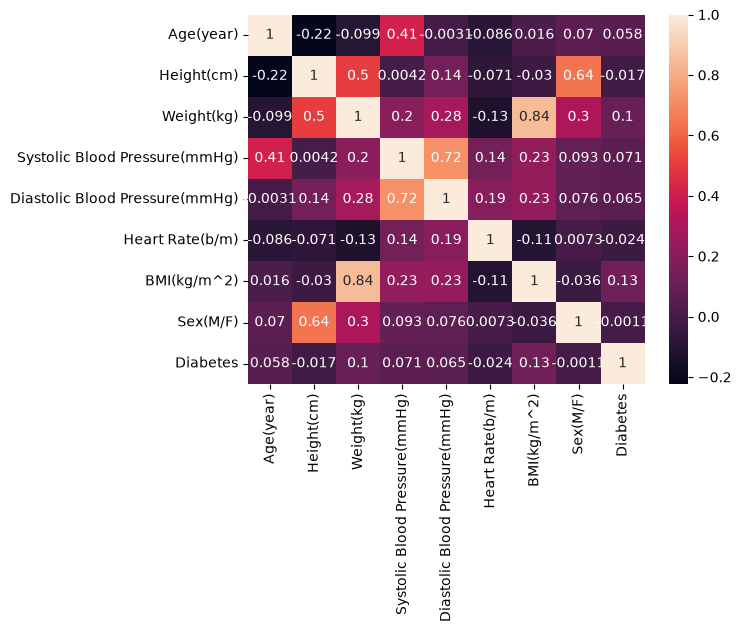

In [24]:
sns.heatmap(pd.concat([X_diabetes, y_diabetes], axis=1).corr(), annot=True)

## Logistic Regression baseline

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold

model = LogisticRegression(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_diabetes, y_diabetes, train_size=0.8, random_state=42, stratify=y_diabetes)

model.fit(X_train, y_train)

cv = cross_validate(model, X_train, y_train, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.528735632183908)

In [26]:
model_xgb = XGBClassifier(eval_metric='logloss')

model_xgb.fit(X_diabetes, y_diabetes)

cv_xgb = cross_validate(model_xgb, X_diabetes, y_diabetes, cv=5, scoring=['roc_auc'])

cv_xgb['test_roc_auc']

array([0.30888031, 0.40972222, 0.34722222, 0.47569444, 0.71031746])

In [27]:
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5)
skf.get_n_splits()

scores = []

for i, (train_index, test_index) in enumerate(skf.split(X_diabetes, y_diabetes)):
    X_train = X_diabetes.iloc[train_index]
    y_train = y_diabetes.iloc[train_index]
    X_test = X_diabetes.iloc[test_index]
    y_test = y_diabetes.iloc[test_index]

    model_xgb = XGBClassifier(eval_metric='logloss')

    model_xgb.fit(X_train, y_train)

    y_pred = model_xgb.predict_proba(X_test)[:, 1]


    scores.append(roc_auc_score(y_test, y_pred))

scores

[0.3088803088803089,
 0.4097222222222222,
 0.3472222222222222,
 0.4756944444444444,
 0.7103174603174602]

In [28]:
y_train

0      0
1      0
2      0
3      0
4      0
      ..
191    1
192    1
193    1
194    1
195    1
Name: Diabetes, Length: 176, dtype: int64

In [29]:
X_train

,Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Sex(M/F)
0,-0.768337,-1.127587,0.236798,1.625816,1.547085,2.180326,1.041372,0
1,-0.452641,-0.516648,-0.859404,1.576631,1.907907,0.220334,-0.706481,0
2,-0.642058,-1.371963,-1.112373,-1.325313,-0.076613,0.500333,-0.555281,0
3,-0.768337,1.316169,0.405444,0.396179,1.907907,1.246997,-0.284352,1
4,-0.705198,-0.761024,0.405444,-0.243232,0.103798,-0.059665,0.988096,0
...,...,...,...,...,...,...,...,...
191,-0.200085,1.071794,-0.016172,0.445364,0.735236,0.686999,-0.587230,1
192,0.305028,2.660236,2.429201,-0.538345,-0.347229,-1.739658,0.868140,1
193,0.431306,-0.883212,-0.775080,-1.472869,-1.159078,0.593666,-0.401205,1
194,0.810141,-0.638836,-0.016172,-0.685902,-0.076613,-0.619663,0.387311,0


In [30]:
cv_xgb['test_roc_auc']

array([0.30888031, 0.40972222, 0.34722222, 0.47569444, 0.71031746])

In [31]:
y_diabetes

0      0
1      0
2      0
3      0
4      0
      ..
214    0
215    0
216    0
217    0
218    0
Name: Diabetes, Length: 219, dtype: int64

# Trying adding more features (HRV, Arterial Stiffness)

In [ ]:
from scipy.signal import butter, filtfilt, find_peaks


In [ ]:
PATH_TABLA_SQI = "ruta/a/tabla_sqi.xlsx"
PATH_SIGNALS = "/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/Data File/0_subject"

FS = 1000 # El paper aclara esta freucencia de muestreo

In [1]:
# aplico filtro pasabandas

def signal_filter(signal, fs, low=0.7, high = 3.5):

    nyq = fs/2
    b, a = butter(3, [low/nyq, high/nyq], bytpe = 'band')
    return filtfilt(b, a,signal)


In [2]:
# extraigo hr, hrv, arterial stifness
def calcular_features(senal, fs):

    senal_filtrada = signal_filter(senal, fs)

    # para detectar los picos, se usa la distancia minima entre picos (0.4s, max 150bpm) (60 segs / 150 lat/min) --> Max de un humano

    picos, _ = find_peaks(senal_filtrada, distance=fs*0.4)

    if len(picos) < 2:
        # Senal de mala calidad, no se pueden calcular features confiables
        return {"hr": np.nan, "hrv_sdnn": np.nan, "sdppg_ratio": np.nan}

    intervalos = np.diff(picos) / fs  # en segundos

    hr = 60 / np.mean(intervalos)
    hrv_sdnn = np.std(intervalos) * 1000  # en milisegundos

    # SDPPG: segunda derivada de la senal filtrada
    primera_derivada = np.gradient(senal_filtrada)
    segunda_derivada = np.gradient(primera_derivada)

    # Simplificacion: tomamos el pico "a" (maximo) y el valle "b" (minimo)
    # en la ventana alrededor de cada latido, y promediamos la razon b/a
    ratios = []
    for i in range(len(picos) - 1):
        ventana = segunda_derivada[picos[i]:picos[i+1]]
        if len(ventana) > 3:
            a = np.max(ventana)
            b = np.min(ventana)
            if a != 0:
                ratios.append(b / a)
    sdppg_ratio = np.mean(ratios) if ratios else np.nan

    return {"hr": hr, "hrv_sdnn": hrv_sdnn, "sdppg_ratio": sdppg_ratio}

#